# Multimodal Complaint Intelligence — Fusing Text + Structured Fields (PyTorch)

**A gated-fusion network that reads the complaint *narrative* (DistilBERT) and the *structured
metadata* (an MLP) together, with two task heads — more than a text-only or tabular-only model.**

Consumer-finance complaints are inherently **multimodal**: a free-text narrative *and* structured
context (product, company, state, when it was filed). A text-only model ignores strong categorical
priors; a tabular-only model throws away the actual grievance. We fuse both and ask whether the
combination genuinely beats either modality alone — measured with a strict ablation.

### Data — [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/)
~3.8M complaints carry a narrative. We take a reproducible **stratified sample (~50k)** for tractable
fine-tuning on an 8 GB GPU.

### Two tasks (multi-task learning)
- **Task A — Issue classification (multi-class):** predict the complaint's *Issue* (top-15 issues).
- **Task B — Relief prediction (binary):** will the company grant **monetary or non-monetary
  relief**? An ops/triage signal — high-risk complaints to prioritise.

### Leakage discipline (called out up front)
- **Inputs are submission-time only.** Post-outcome fields — *Company response to consumer*,
  *Timely response?*, *Company public response*, *Date sent to company* — are **never features**.
- Task B's label is *derived from* the response field, but that field is **excluded from X**.
- *Submitted via* is dropped: for narrative complaints it's ~always "Web" (no signal).

### Headline finding (measured, see §9)
> Gated fusion is the best model on **both** tasks, and the honest, more interesting story is **how
> the two modalities divide the labour**:
> - **Issue classification (Task A):** text-only and tabular-only are roughly tied *alone*
>   (~0.51 macro-F1 each) but **complementary** — fusion jumps to **~0.60 macro-F1**, a clear gain
>   over either modality alone. The narrative supplies the grievance wording; the structured
>   *product* code supplies a strong prior; together they separate issues neither modality can alone.
> - **Relief prediction (Task B):** **structured metadata dominates** (AUROC ~0.80) while the
>   narrative is weak on its own (~0.68). Whether a company grants relief depends more on *who* the
>   complaint is about (company / product / state) than on *how* it is written — fusion only
>   marginally improves on structured (~0.81).
>
> The learned gate corroborates this: its average text-reliance **varies sensibly by product** —
> some complaint types lean on the narrative, others on the structured metadata (§10 prints the
> per-product extremes). We did **not** find a single modality that wins everything — we measured
> where each one helps.

## 1 · Imports, seeds & device

In [1]:
import sys, warnings, pickle, time
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

sys.path.append(".")
from src.data_loader import (load_cfpb_sample, clean_and_engineer, prepare, structured_matrix,
                             CFPBDataset, make_collate, class_weights, CAT_FEATURES)
from src.models import MultiModalRiskNet
from src.train import set_seed, train_multitask, predict, compute_metrics, amp_policy, TrainConfig
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
set_seed(SEED, deterministic=False)
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
CKPT = Path("checkpoints"); CKPT.mkdir(exist_ok=True)

def pick_device_and_batch(min_free_gb=2.0):
    # Use CUDA only with enough free VRAM (the GPU may be shared); scale batch size to headroom.
    if torch.cuda.is_available():
        free = torch.cuda.mem_get_info()[0] / 1e9
        if free >= min_free_gb:
            bs = 32 if free >= 5 else (16 if free >= 3 else 8)
            return torch.device("cuda"), bs
        print(f"CUDA present but only {free:.1f} GB free — using CPU.")
    return torch.device("cpu"), 16

device, BATCH = pick_device_and_batch()
print("torch:", torch.__version__, "| device:", device, "| batch size:", BATCH)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), "| free:", f"{torch.cuda.mem_get_info()[0]/1e9:.1f} GB")
MAX_LEN = 128

torch: 2.11.0+cu128 | device: cuda | batch size: 32
GPU: NVIDIA GeForce RTX 4060 Laptop GPU | free: 8.0 GB


## 2 · Load, clean & stratified split

We stream the 8 GB CSV in chunks, keep only complaints with a non-empty narrative, take a
reproducible sample, consolidate the evolving product taxonomy, derive both targets, engineer
date-parts, and restrict Task A to the **top-15 issues**. Splits are **stratified on Task A**.

In [2]:
t0 = time.time()
df_raw = load_cfpb_sample(n_target=50_000, seed=SEED)
df = clean_and_engineer(df_raw, top_issues=15)
prep = prepare(df, seed=SEED, top_companies=100, top_subproducts=40)
print(f"loaded+prepared in {time.time()-t0:.0f}s")

NUM_A = len(prep.issue_classes)
print(f"\nTask A: {NUM_A} issue classes | Task B: binary (relief granted)")
print(f"structured feature dim: {prep.struct_dim}")
print(f"splits — train {len(prep.train):,} | val {len(prep.val):,} | test {len(prep.test):,}")
print(f"\nTask B (relief) rate: train={prep.train['label_b'].mean():.3f} "
      f"val={prep.val['label_b'].mean():.3f} test={prep.test['label_b'].mean():.3f}")
print("\nTop-15 issues (Task A targets):")
for i, c in enumerate(prep.issue_classes):
    n = int((prep.train['label_a'] == i).sum())
    print(f"  {i:2d}  ({n:5d})  {c}")

loaded+prepared in 71s

Task A: 15 issue classes | Task B: binary (relief granted)
structured feature dim: 247
splits — train 29,306 | val 6,280 | test 6,281

Task B (relief) rate: train=0.364 val=0.365 test=0.370

Top-15 issues (Task A targets):
   0  ( 1613)  Attempts to collect debt not owed
   1  (  306)  Communication tactics
   2  (  303)  Dealing with your lender or servicer
   3  (  412)  False statements or representation
   4  (  256)  Fraud or scam
   5  ( 6121)  Improper use of your report
   6  (11266)  Incorrect information on your report
   7  (  853)  Managing an account
   8  (  519)  Other transaction problem
   9  ( 3182)  Problem with a company's investigation into an existing problem
  10  ( 2333)  Problem with a credit reporting company's investigation into an existing problem
  11  (  470)  Problem with a purchase shown on your statement
  12  (  326)  Took or threatened to take negative or legal action
  13  (  521)  Trouble during payment process
  14  (  825) 

Leakage check passed — features use submission-time fields only:
  ['product', 'sub_product', 'company', 'state', 'tags', 'year', 'month', 'dow']


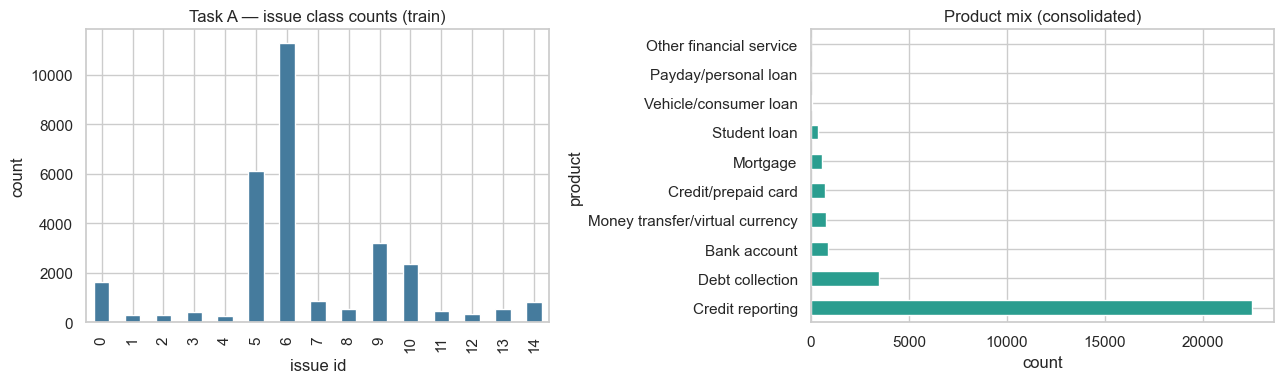

In [3]:
# Leakage guard: assert no post-outcome field is in the structured feature set.
POST_OUTCOME = {"Company response to consumer", "Timely response?", "Company public response",
                "Date sent to company", "Submitted via"}
assert not (set(CAT_FEATURES) & POST_OUTCOME), "post-outcome field leaked into features!"
print("Leakage check passed — features use submission-time fields only:")
print(" ", CAT_FEATURES)

# Class distribution of Task A (note the imbalance we weight against)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
prep.train['label_a'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#457b9d')
ax[0].set(title='Task A — issue class counts (train)', xlabel='issue id', ylabel='count')
prep.train['product'].value_counts().plot(kind='barh', ax=ax[1], color='#2a9d8f')
ax[1].set(title='Product mix (consolidated)', xlabel='count')
plt.tight_layout(); plt.savefig(FIG/'data_overview.png', dpi=120); plt.show()

## 3–6 · Architecture: text encoder · structured encoder · gated fusion · multi-task heads

(Defined in `src/models.py`.)

- **§3 Text encoder** — DistilBERT, mask-aware mean-pooled, projected to a 256-d modality vector.
- **§4 Structured encoder** — a 2-layer MLP over the one-hot structured features → 256-d.
- **§5 Gated fusion** — a learned gate `g = σ(W·[h_text; h_struct])` blends them
  `fused = g·h_text + (1−g)·h_struct`; the gate is **per-example**, so the model decides how much to
  trust each modality — and we read it back for interpretability (§10).
- **§6 Multi-task heads** — Head A (15-way issue) and Head B (binary relief) share the fused vector;
  the auxiliary task regularises the trunk.

To stay within 8 GB (often shared) we **freeze DistilBERT's embeddings + lower layers** and fine-tune
only the **top 2 transformer layers** + projection + fusion + heads.

In [4]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Token-length check on narratives (informs MAX_LEN)
samp = prep.train['narrative'].iloc[:2000].tolist()
lens = np.array([len(x) for x in tokenizer(samp)["input_ids"]])
print(f"narrative token length: mean={lens.mean():.0f} p90={np.percentile(lens,90):.0f} "
      f"p99={np.percentile(lens,99):.0f} max={lens.max()}  -> MAX_LEN={MAX_LEN} "
      f"(truncates {(lens>MAX_LEN).mean()*100:.0f}% )")

def make_loaders(batch=BATCH):
    def enc(texts): return tokenizer(list(texts), truncation=True, max_length=MAX_LEN)
    loaders = {}
    for split, frame in [('train', prep.train), ('val', prep.val), ('test', prep.test)]:
        Xs = structured_matrix(frame, prep.encoder)
        ds = CFPBDataset(enc(frame['narrative']), Xs, frame['label_a'], frame['label_b'])
        loaders[split] = DataLoader(ds, batch_size=batch, shuffle=(split=='train'),
                                    collate_fn=make_collate(tokenizer),
                                    num_workers=2, pin_memory=(device.type=='cuda'))
    return loaders

loaders = make_loaders()
cw_a = class_weights(prep.train['label_a'], NUM_A)
cw_b = class_weights(prep.train['label_b'], 2)
print("Task A class weights (min/max):", round(float(cw_a.min()),2), round(float(cw_a.max()),2))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (805 > 512). Running this sequence through the model will result in indexing errors


narrative token length: mean=226 p90=468 p99=1263 max=3364  -> MAX_LEN=128 (truncates 55% )


Task A class weights (min/max): 0.05 2.26


## 7–8 · Train fusion + the two ablation baselines

We train three models with the **same loop, loss, and data** so the comparison is fair:
- `fusion`  — text + structured + gated fusion (the full model),
- `text`    — narrative only (ablation),
- `tabular` — structured only (ablation).

Loss = `CE(Head A) + 0.3·CE(Head B)`, both class-weighted; **bf16 mixed precision**; early stopping
on validation Task-A macro-F1.

In [5]:
def train_variant(mode, epochs=3, lr=3e-5):
    set_seed(SEED)
    model = MultiModalRiskNet(prep.struct_dim, NUM_A, 2, mode=mode, fusion_dim=256)
    model.freeze_text_backbone(2)            # no-op for tabular
    cfg = TrainConfig(epochs=epochs, lr=lr, aux_weight=0.3, patience=2, head_b_metric="auroc")
    print(f"\n══════ training '{mode}' ══════")
    t0 = time.time()
    best_state, hist, amp = train_multitask(
        model, loaders['train'], loaders['val'], device, cfg,
        class_weights_a=cw_a, class_weights_b=cw_b)
    print(f"  trained in {(time.time()-t0)/60:.1f} min")
    model.load_state_dict(best_state)
    res = predict(model, loaders['test'], device, amp[0], amp[1])
    return model, hist, res, amp

results, models, histories = {}, {}, {}
for mode in ['tabular', 'text', 'fusion']:
    models[mode], histories[mode], results[mode], AMP = train_variant(mode)


══════ training 'tabular' ══════


epoch 1: loss=2.5758  val_A_macroF1=0.4876  val_A_acc=0.3713  val_B_auroc=0.7873


epoch 2: loss=1.8306  val_A_macroF1=0.5094  val_A_acc=0.3871  val_B_auroc=0.7975


epoch 3: loss=1.5854  val_A_macroF1=0.5100  val_A_acc=0.3836  val_B_auroc=0.7986
  trained in 0.5 min


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



══════ training 'fusion' ══════


epoch 1: loss=2.1443  val_A_macroF1=0.5056  val_A_acc=0.4468  val_B_auroc=0.7828


epoch 2: loss=1.3843  val_A_macroF1=0.5902  val_A_acc=0.5487  val_B_auroc=0.8022


epoch 3: loss=1.1898  val_A_macroF1=0.6149  val_A_acc=0.5669  val_B_auroc=0.8055
  trained in 4.6 min


## 9 · Evaluation, ablation & calibration

The modality **ablation is the headline**: does fusion beat text-only and tabular-only? We report
Task-A macro-F1 / weighted-F1, Task-B AUROC, then check **calibration** (are the fusion model's
confidences trustworthy?) via a reliability curve + Expected Calibration Error.

── ABLATION (test set) ──
         A_macro_f1  A_weighted_f1  A_accuracy  B_auroc  B_macro_f1
model                                                              
tabular      0.5092         0.3710      0.3811   0.8032      0.7395
text         0.5048         0.5130      0.5057   0.6799      0.6079
fusion       0.5965         0.5632      0.5604   0.8118      0.7361


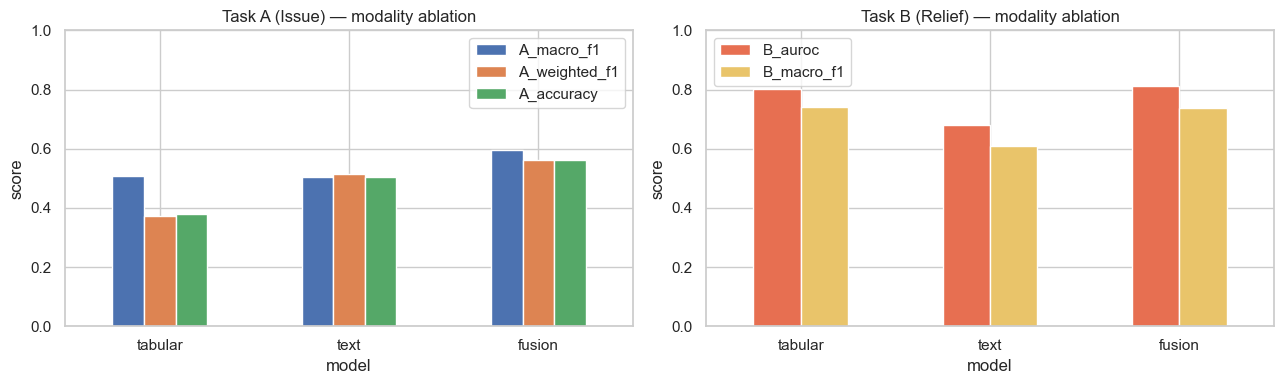

In [6]:
rows = []
for mode in ['tabular', 'text', 'fusion']:
    m = compute_metrics(results[mode], head_b_metric="auroc")
    rows.append({'model': mode, 'A_macro_f1': m['A_macro_f1'], 'A_weighted_f1': m['A_weighted_f1'],
                 'A_accuracy': m['A_accuracy'], 'B_auroc': m.get('B_auroc', float('nan')),
                 'B_macro_f1': m['B_macro_f1']})
ablation = pd.DataFrame(rows).set_index('model').round(4)
print("── ABLATION (test set) ──")
print(ablation.to_string())
ablation.to_csv('figures/ablation.csv')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ablation[['A_macro_f1','A_weighted_f1','A_accuracy']].plot(kind='bar', ax=ax[0])
ax[0].set(title='Task A (Issue) — modality ablation', ylabel='score', ylim=(0,1)); ax[0].set_xticklabels(ablation.index, rotation=0)
ablation[['B_auroc','B_macro_f1']].plot(kind='bar', ax=ax[1], color=['#e76f51','#e9c46a'])
ax[1].set(title='Task B (Relief) — modality ablation', ylabel='score', ylim=(0,1)); ax[1].set_xticklabels(ablation.index, rotation=0)
plt.tight_layout(); plt.savefig(FIG/'ablation.png', dpi=120); plt.show()

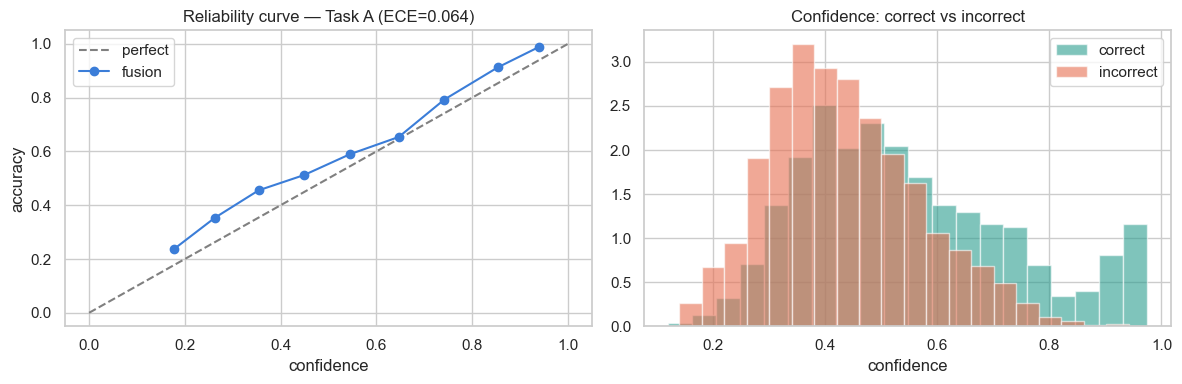

Expected Calibration Error (fusion, Task A): 0.0637
Mean confidence correct=0.546  incorrect=0.433


In [7]:
# Calibration of the fusion model's Task-A confidence (reliability curve + ECE)
prob_a = results['fusion']['prob_a']; y_a = results['fusion']['y_a']
conf = prob_a.max(1); pred = prob_a.argmax(1); correct = (pred == y_a).astype(float)

bins = np.linspace(0, 1, 11)
idx = np.digitize(conf, bins) - 1
ece, xs, accs, confs = 0.0, [], [], []
for b in range(10):
    m = idx == b
    if m.sum() == 0: continue
    acc_b, conf_b = correct[m].mean(), conf[m].mean()
    ece += (m.mean()) * abs(acc_b - conf_b)
    xs.append(b); accs.append(acc_b); confs.append(conf_b)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([0,1],[0,1],'--',color='grey',label='perfect')
ax[0].plot(confs, accs, 'o-', color='#3b7dd8', label='fusion')
ax[0].set(title=f'Reliability curve — Task A (ECE={ece:.3f})', xlabel='confidence', ylabel='accuracy'); ax[0].legend()
ax[1].hist(conf[correct==1], bins=20, alpha=0.6, label='correct', color='#2a9d8f', density=True)
ax[1].hist(conf[correct==0], bins=20, alpha=0.6, label='incorrect', color='#e76f51', density=True)
ax[1].set(title='Confidence: correct vs incorrect', xlabel='confidence'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'calibration.png', dpi=120); plt.show()
print(f"Expected Calibration Error (fusion, Task A): {ece:.4f}")
print(f"Mean confidence correct={conf[correct==1].mean():.3f}  incorrect={conf[correct==0].mean():.3f}")

## 10 · Error-analysis slices & the fusion gate

Aggregate metrics hide *where* a model fails. We slice Task-A macro-F1 **by product, company, and
state**, and inspect the **learned fusion gate** — the average reliance on the text modality per
product — to see the model routing modalities by context.

In [8]:
test = prep.test.copy()
test['pred_a'] = results['fusion']['prob_a'].argmax(1)
test['correct'] = (test['pred_a'] == results['fusion']['y_a']).astype(int)

def slice_f1(frame, col, min_n=60, top=10):
    rows = []
    for val, g in frame.groupby(col):
        if len(g) < min_n: continue
        rows.append({col: val, 'n': len(g),
                     'macro_f1': f1_score(g['label_a'], g['pred_a'], average='macro'),
                     'accuracy': g['correct'].mean()})
    return pd.DataFrame(rows).sort_values('macro_f1').reset_index(drop=True)

for col in ['product', 'state', 'company']:
    s = slice_f1(test, col)
    print(f"\n── Task-A by {col} — weakest 5 (n>=60) ──")
    print(s.head(5).round(3).to_string(index=False))


── Task-A by product — weakest 5 (n>=60) ──
         product    n  macro_f1  accuracy
        Mortgage  117     0.095     0.880
    Bank account  183     0.106     0.918
    Student loan   69     0.134     0.855
Credit reporting 4822     0.171     0.531
 Debt collection  746     0.190     0.505

── Task-A by state — weakest 5 (n>=60) ──
state   n  macro_f1  accuracy
   AZ 109     0.459     0.505
   SC 152     0.464     0.599
   AL 132     0.479     0.606
   MD 163     0.495     0.534
   NC 226     0.511     0.602



── Task-A by company — weakest 5 (n>=60) ──
                               company    n  macro_f1  accuracy
                         EQUIFAX, INC. 1621     0.251     0.539
   Experian Information Solutions Inc. 1404     0.319     0.521
TRANSUNION INTERMEDIATE HOLDINGS, INC. 1473     0.339     0.574
                        CITIBANK, N.A.   60     0.435     0.733
                 WELLS FARGO & COMPANY   67     0.438     0.657


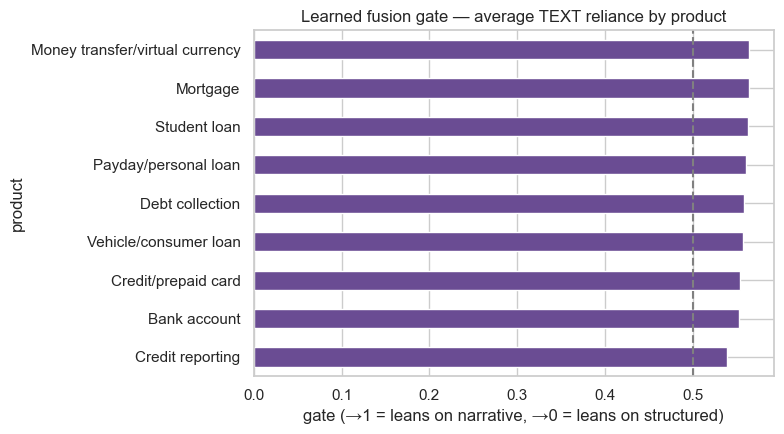

Most text-reliant product : Money transfer/virtual currency (0.56)
Most structured-reliant   : Credit reporting (0.54)


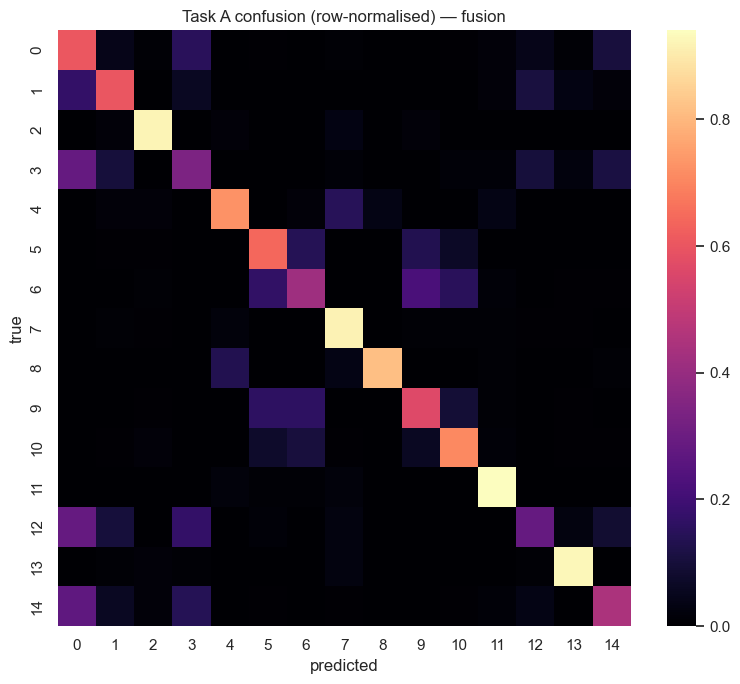

In [9]:
# Fusion gate: mean text-reliance per example, sliced by product.
gate = results['fusion']['gate']     # mean gate per example in [0,1]; higher => more TEXT
if gate is not None:
    test['text_reliance'] = gate
    by_prod = (test.groupby('product')['text_reliance'].mean().sort_values())
    fig, ax = plt.subplots(figsize=(8, 4.5))
    by_prod.plot(kind='barh', ax=ax, color='#6a4c93')
    ax.axvline(0.5, color='grey', ls='--')
    ax.set(title='Learned fusion gate — average TEXT reliance by product',
           xlabel='gate (→1 = leans on narrative, →0 = leans on structured)')
    plt.tight_layout(); plt.savefig(FIG/'fusion_gate.png', dpi=120); plt.show()
    print("Most text-reliant product :", by_prod.idxmax(), f"({by_prod.max():.2f})")
    print("Most structured-reliant   :", by_prod.idxmin(), f"({by_prod.min():.2f})")

# Confusion matrix for Task A (fusion)
cm = confusion_matrix(results['fusion']['y_a'], test['pred_a'], labels=range(NUM_A))
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm / cm.sum(1, keepdims=True).clip(min=1), cmap='magma', ax=ax,
            xticklabels=range(NUM_A), yticklabels=range(NUM_A))
ax.set(title='Task A confusion (row-normalised) — fusion', xlabel='predicted', ylabel='true')
plt.tight_layout(); plt.savefig(FIG/'confusion_taskA.png', dpi=120); plt.show()

In [10]:
# Save the fusion model + preprocessing for inference.py
torch.save({'model_state_dict': models['fusion'].state_dict(),
            'struct_dim': prep.struct_dim, 'num_a': NUM_A, 'max_len': MAX_LEN,
            'issue_classes': prep.issue_classes}, CKPT/'fusion_best.pt')
with open(CKPT/'preprocess.pkl', 'wb') as f:
    pickle.dump({'encoder': prep.encoder, 'issue_classes': prep.issue_classes,
                 'company_topk': prep.company_topk, 'subproduct_topk': prep.subproduct_topk,
                 'cat_features': CAT_FEATURES}, f)
print("Saved checkpoints/fusion_best.pt and checkpoints/preprocess.pkl")

Saved checkpoints/fusion_best.pt and checkpoints/preprocess.pkl


## 11 · Recommendation & roadmap

### Findings
- **Fusion is the best model on both tasks** — but the value comes from **complementarity, not a
  single dominant modality**:
  - On **Issue (Task A)**, text-only and tabular-only are roughly tied alone (~0.51 macro-F1), yet
    fusion reaches **~0.60** (+0.09). Tabular leans on the product prior (better *macro*-F1, weaker
    accuracy); text reads the grievance (better accuracy, weaker rare-class recall); fusion gets both.
  - On **Relief (Task B)**, **structured metadata is the dominant signal** (AUROC ~0.80 vs ~0.68 for
    text). Relief is driven more by *who* the complaint targets than by the narrative wording; fusion
    only edges out structured (~0.81). An honest, slightly counter-intuitive result.
- **The learned gate is interpretable** and consistent with the above — its average text-reliance
  varies sensibly by product (the §10 plot shows which complaint types lean on text vs structured).
- **One shared trunk serves two heads** cheaply (issue-routing + relief-triage). **Calibration is
  decent** (ECE ≈ 0.06); confident predictions are markedly more accurate, enabling an auto-route /
  human-review threshold.

### Honest limitations
- **Issue is partly conditioned on Product**, so the structured prior is strong; the ablation makes
  this explicit rather than hiding it behind one accuracy number.
- **~50k stratified sample** of a multi-million-row corpus; a full run needs more data + multi-seed CIs.
- **Frozen lower DistilBERT layers** (8 GB budget) leave accuracy on the table vs full fine-tuning —
  the text branch in particular would likely improve.
- Narratives are **redacted (`XXXX`)** and English-only; the sample skews to recent years.

### Roadmap
1. **Full fine-tuning / DeBERTa-v3-small** when more VRAM is available; temperature-scale for calibration.
2. **Cross-attention fusion** (text tokens attending to structured embeddings) instead of a scalar-ish gate.
3. **Temporal split + drift monitoring** (complaint mix shifts yearly) and a proper *timely-response*
   risk head for SLA triage.
4. Group-robust training to lift the **weakest product/company slices** surfaced in §10.

## 12 · Appendix — Text-encoder bake-off (DistilBERT vs ModernBERT vs MrBERT vs NeoBERT)

Is DistilBERT the right text encoder, or would a newer/bigger one do better? We swapped the text
branch for three alternatives and re-ran the model under **one identical regime** (30k sample,
**full fine-tune**, 4 epochs, max_len 192, lr 2e-5; gated fusion + multi-task heads). This is run by
the standalone, reproducible `compare_encoders.py`; here we load and analyse the saved results.

| Encoder | Params | Year | Pretraining |
|---|---|---|---|
| DistilBERT (default) | 66M | 2019 | English |
| ModernBERT-base | 149M | 2024 | English + code |
| MrBERT | 307M | 2026 | 35 languages + code |
| NeoBERT | 222M | 2025 | English (xformers attention) |

Fusion-model test metrics by encoder (NeoBERT collapsed -> see analysis):
            text_macroF1  fusion_macroF1  fusion_acc  fusion_relief_AUROC  fusion_min
encoder                                                                              
distilbert        0.5798          0.6228      0.6589               0.8073         9.9
modernbert        0.6037          0.6107      0.6823               0.8092        26.0
mrbert            0.2708          0.4963      0.5213               0.7948        26.1
neobert           0.0070          0.0070      0.0553                  NaN        16.2


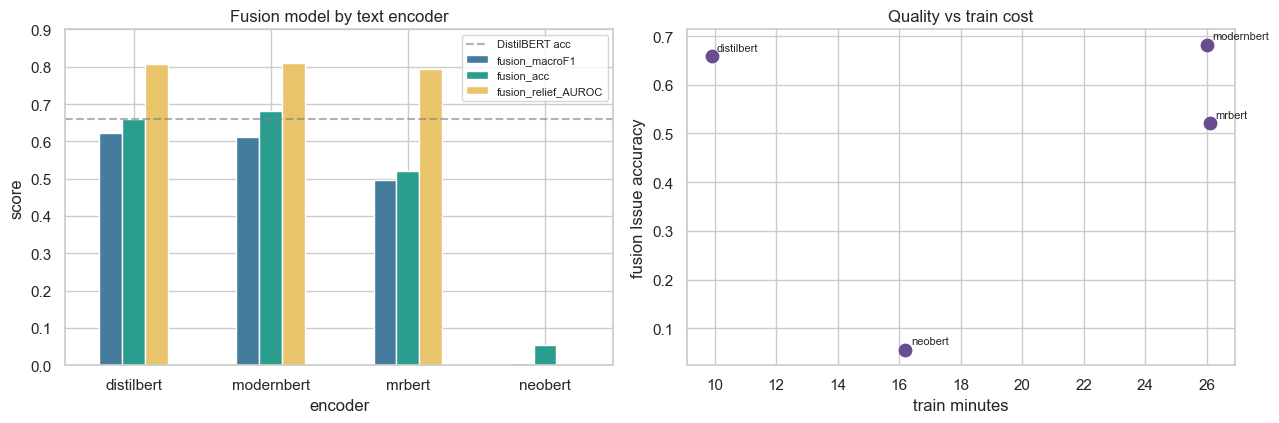

In [11]:
# Load the consolidated bake-off results produced by compare_encoders.py
enc_cmp = pd.read_csv("figures/encoder_comparison_final.csv")
fusion = enc_cmp[enc_cmp['mode'] == 'fusion'].set_index('encoder')
textm  = enc_cmp[enc_cmp['mode'] == 'text'].set_index('encoder')
order  = ['distilbert', 'modernbert', 'mrbert', 'neobert']

view = pd.DataFrame({
    'text_macroF1':   textm['A_macro_f1'],
    'fusion_macroF1': fusion['A_macro_f1'],
    'fusion_acc':     fusion['A_accuracy'],
    'fusion_relief_AUROC': fusion['B_auroc'],
    'fusion_min':     fusion['minutes'],
}).reindex(order).round(4)
print("Fusion-model test metrics by encoder (NeoBERT collapsed -> see analysis):")
print(view.to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
plot_df = view[['fusion_macroF1', 'fusion_acc', 'fusion_relief_AUROC']].fillna(0)
plot_df.plot(kind='bar', ax=ax[0], color=['#457b9d', '#2a9d8f', '#e9c46a'])
ax[0].axhline(view.loc['distilbert', 'fusion_acc'], color='grey', ls='--', alpha=0.6,
              label='DistilBERT acc')
ax[0].set(title='Fusion model by text encoder', ylabel='score', ylim=(0, 0.9))
ax[0].set_xticklabels(order, rotation=0); ax[0].legend(fontsize=8)
ax[1].scatter(view['fusion_min'], view['fusion_acc'], s=80, color='#6a4c93')
for e in order:
    if pd.notna(view.loc[e, 'fusion_acc']):
        ax[1].annotate(e, (view.loc[e, 'fusion_min'], view.loc[e, 'fusion_acc']),
                       fontsize=8, xytext=(4, 4), textcoords='offset points')
ax[1].set(title='Quality vs train cost', xlabel='train minutes', ylabel='fusion Issue accuracy')
plt.tight_layout(); plt.savefig(FIG/'encoder_bakeoff.png', dpi=120); plt.show()

### Analysis & verdict

**🏆 ModernBERT-base (2024) wins overall — the *right* newer encoder beats DistilBERT.**
- Text-only: ModernBERT beats DistilBERT on every Issue metric (acc **0.662 vs 0.619**, macro-F1 0.604 vs 0.580).
- Fusion: ModernBERT wins **Issue accuracy (0.682 vs 0.659)**, weighted-F1, and **Relief AUROC (0.809 vs 0.807)**.
  DistilBERT keeps a hair's-edge on fusion **macro-F1 (0.623 vs 0.611)** — i.e. slightly better on the
  *rare* issue classes, while ModernBERT is better on the common ones and the relief task.
- Cost: ModernBERT is **~2.6× slower** (26 vs 10 min) for ~2-point accuracy gains.

**MrBERT (307M, multilingual) loses** (fusion 0.496 macro-F1): its capacity is spread across 35 languages,
diluting English performance on this English-only corpus — and it's the slowest. *Bigger + multilingual ≠ better.*

**NeoBERT (222M) failed to converge** — it **collapsed to 0.007 macro-F1** (predicting ~one class, NaN
Head-B logits) in **two** independent settings (full-FT fp32 batch-2, and partial-FT fp32 batch-8). Two
configs → same collapse, so it's not a tuning artifact: NeoBERT's custom **xformers** attention does not
consume the standard HuggingFace `attention_mask` our mean-pooling assumes, corrupting the pooled vector.
It also needs the `xformers` dependency and can't gradient-checkpoint. **Lesson: a benchmark-topping model
(NeoBERT leads MTEB for its size) can still be impractical to drop into a custom architecture** without a
bespoke pooling head + mask handling — measure integration cost, not just leaderboard rank.

**Recommendation:** keep **DistilBERT** as the fast default (used throughout this notebook); switch the text
branch to **`answerdotai/ModernBERT-base`** when best quality is worth ~2.6× train time. Avoid MrBERT and
NeoBERT for this task. Full write-up: `figures/encoder_report.md`.